# Análisis de sentimiento y respuesta a las interrogantes

**CC3084 · Ciencia de Datos · Universidad del Valle de Guatemala · Semestre II, 2026**

Este cuaderno cubre los **ejercicios 8 y 9** del enunciado:

- **Ejercicio 8:** determinar las palabras positivas, negativas y neutras; medir a partir de
  ellas qué tan positivo o negativo es cada tweet; y responder si vale la pena conservar los
  emoticones para analizarlos.
- **Ejercicio 9:** los 10 tweets más negativos y los 10 más positivos con su categoría, y si
  los tweets de desastre real son más negativos que los demás.

Produce además `data/processed/tweets_con_sentimiento.parquet`, que es el insumo con el que
el ejercicio 10 reentrena el clasificador.

La herramienta principal es **VADER**, del módulo `nltk.sentiment.vader`. El detalle de por
qué se eligió está en `src/sentimiento.py` y en la sección del informe; en resumen: el corpus
es en inglés, VADER está calibrado sobre texto de redes sociales, y maneja de forma nativa la
negación, los intensificadores, las mayúsculas y los emoticones. Como el conjunto **no tiene
etiquetas de sentimiento** —su única etiqueta dice si el tweet habla de un desastre real, no
si es positivo o negativo— un enfoque basado en léxico no es una comodidad sino la única vía
disponible.

In [1]:
import sys
import collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ / 'src'))

import config
from carga import cargar_tweets
from preprocesamiento import pipeline_texto, limpiar_sentimiento, tokenizar
import sentimiento as sent

config.asegurar_directorios()

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = config.FIG_DPI
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.width', 170)
pd.set_option('display.max_colwidth', 95)

def guardar(fig, nombre):
    ruta = config.FIGURES / nombre
    fig.savefig(ruta)
    print(f'figura guardada: {ruta.name}')
    return ruta

def guardar_tabla(df, nombre, index=False):
    ruta = config.TABLES / nombre
    df.to_csv(ruta, index=index, encoding='utf-8')
    print(f'tabla guardada: {ruta.name}')
    return ruta

print(f'Umbrales de polaridad: positivo >= {config.UMBRAL_POSITIVO}, '
      f'negativo <= {config.UMBRAL_NEGATIVO}')
print(f'TextBlob disponible: {sent.textblob_disponible()}')

Umbrales de polaridad: positivo >= 0.05, negativo <= -0.05
TextBlob disponible: True


## Preparación: las cuatro versiones del texto

Se construyen cuatro versiones del mismo tweet porque el ejercicio 8 necesita compararlas
entre sí. La comparación no es un adorno: es la evidencia con la que se responde la pregunta
del enunciado sobre los emoticones.

| Columna | Qué conserva | Para qué sirve |
|---|---|---|
| `text` | todo, tal como se escribió | referencia |
| `text_clean` | limpieza agresiva: sin mayúsculas, sin puntuación, sin stopwords | clasificación por tema (ejercicio 6) |
| `text_sent` | limpieza conservadora de `preprocesamiento.py`, con emoticones **traducidos** a `emoji_feliz` | contrato del equipo |
| `text_vader` | igual que la anterior pero con emoticones **literales** | puntuar con VADER |

In [2]:
df = cargar_tweets(deduplicar=True, verbose=True)

df['text_clean'] = df['text'].apply(
    lambda t: ' '.join(pipeline_texto(t, modo='clasificacion', reduccion='lema', quitar_numeros=False)))
df['text_sent'] = df['text'].apply(limpiar_sentimiento)
df['text_vader'] = df['text'].apply(sent.texto_para_vader)

print()
ejemplo = df.loc[df.text.str.contains(r':D|:\)', regex=True, na=False)].iloc[0]
for col in ['text', 'text_clean', 'text_sent', 'text_vader']:
    print(f'{col:12s}: {ejemplo[col]}')

Leído train.csv: 7,613 filas x 5 columnas
Deduplicación
  Filas originales................. 7,613
  Textos con etiqueta contradictoria 18 (55 filas eliminadas)
  Duplicados exactos eliminados.... 73
  Filas finales.................... 7,485 (128 eliminadas en total)



text        : Cooool :)
text_clean  : cooool
text_sent   : Cooool emoji_feliz
text_vader  : Cooool :)


---

# Ejercicio 8

## Nivel de palabra: qué palabras son positivas, negativas y neutras

El enunciado pide *"determinar las palabras positivas, negativas o neutras"*. El léxico de
VADER trae más de 7,500 términos puntuados a mano por anotadores humanos en una escala de
-4 a +4, pero listarlos todos no diría nada sobre **este** corpus. Lo que interesa es la
intersección: qué palabras del léxico aparecen efectivamente en estos tweets.

In [3]:
vocabulario = collections.Counter(w for t in df.text_clean for w in t.split())
lexico = sent.lexico_del_corpus(vocabulario.keys())
lexico['frecuencia'] = lexico.palabra.map(vocabulario)

guardar_tabla(lexico.sort_values('valencia'), 'sentimiento_lexico_corpus.csv')

print(f'Vocabulario del corpus (text_clean): {len(vocabulario):,} palabras distintas')
print(f'Presentes en el lexico de VADER:     {len(lexico):,} ({len(lexico)/len(vocabulario)*100:.2f}%)')
print()
print(lexico.polaridad.value_counts().to_string())

tabla guardada: sentimiento_lexico_corpus.csv
Vocabulario del corpus (text_clean): 13,348 palabras distintas
Presentes en el lexico de VADER:     1,323 (9.91%)

polaridad
negativa    729
positiva    594


figura guardada: sentimiento_lexico_palabras.png


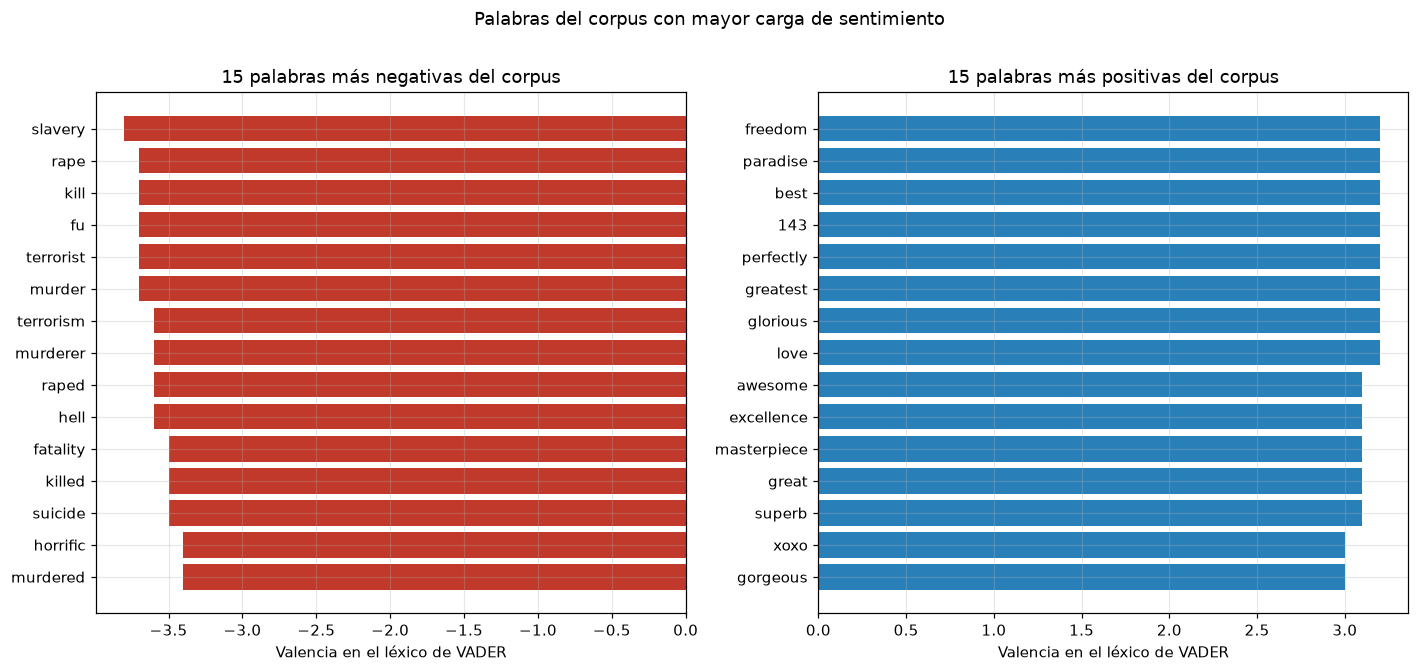

Las 10 más negativas, con su frecuencia en el corpus:


,palabra,valencia,frecuencia
0,slavery,-3.8,1
1,rape,-3.7,5
2,kill,-3.7,68
3,fu,-3.7,1
4,terrorist,-3.7,48
5,murder,-3.7,43
6,terrorism,-3.6,40
7,murderer,-3.6,34
8,raped,-3.6,1
9,hell,-3.6,25


Las 10 más positivas:


,palabra,valencia,frecuencia
0,freedom,3.2,5
1,paradise,3.2,1
2,best,3.2,75
3,143,3.2,1
4,perfectly,3.2,2
5,greatest,3.2,8
6,glorious,3.2,3
7,love,3.2,107
8,awesome,3.1,16
9,excellence,3.1,1


In [4]:
top_neg = lexico.nsmallest(15, 'valencia')
top_pos = lexico.nlargest(15, 'valencia')

fig, axes = plt.subplots(1, 2, figsize=(config.FIG_ANCHO + 3, config.FIG_ALTO + 1))

axes[0].barh(top_neg.palabra[::-1], top_neg.valencia[::-1], color=config.COLOR_DESASTRE)
axes[0].set_title('15 palabras más negativas del corpus')
axes[0].set_xlabel('Valencia en el léxico de VADER')

axes[1].barh(top_pos.palabra[::-1], top_pos.valencia[::-1], color=config.COLOR_NO_DESASTRE)
axes[1].set_title('15 palabras más positivas del corpus')
axes[1].set_xlabel('Valencia en el léxico de VADER')

fig.suptitle('Palabras del corpus con mayor carga de sentimiento', y=1.01)
fig.tight_layout()
guardar(fig, 'sentimiento_lexico_palabras.png')
plt.show()

print('Las 10 más negativas, con su frecuencia en el corpus:')
display(top_neg.head(10)[['palabra', 'valencia', 'frecuencia']].reset_index(drop=True))
print('Las 10 más positivas:')
display(top_pos.head(10)[['palabra', 'valencia', 'frecuencia']].reset_index(drop=True))

**Interpretación.** Solo **1,323 de las 13,348 palabras** del vocabulario están en el léxico
de VADER, un 9.91%: 729 negativas y 594 positivas. Esa cifra por sí sola ya es un resultado:
**nueve de cada diez palabras del corpus no cargan sentimiento según el léxico**. Son nombres
propios, lugares, números, verbos neutros y vocabulario técnico. El sentimiento de un tweet se
decide con una fracción pequeña de lo que dice.

Las palabras más negativas presentes son `slavery`, `rape`, `murder`, `kill`, `terrorist`,
`hell` y `terrorism`, todas con valencia entre -3.8 y -3.6. Las más positivas son `greatest`,
`glorious`, `freedom`, `love`, `paradise` y `best`, alrededor de +3.2.

Conviene mirar también la columna de frecuencia, porque valencia y presencia son cosas
distintas. `slavery` tiene la valencia más negativa del corpus (-3.8) pero aparece **una sola
vez**: su carga es máxima y su influencia agregada es nula. `kill` (-3.7, 68 apariciones),
`terrorist` (-3.7, 48) y `murder` (-3.7, 43) sí mueven la aguja. Del lado positivo pasa lo
mismo: `paradise` y `superb` aparecen una vez cada una, mientras que `love` aparece 107 veces
y `best` 75. **Las palabras que determinan el sentimiento del corpus no son las más extremas
sino las que combinan carga alta con frecuencia alta.**

## Nivel de tweet: contar palabras positivas y negativas

El enunciado continúa: *"teniendo en cuenta la cantidad de palabras positivas y negativas del
tweet determine qué tan positivo, negativo o neutral es el mismo"*. Se implementa
literalmente con `contar_palabras`, que cuenta cuántos tokens de cada tweet son positivos,
negativos o neutros según el léxico, y define el **balance** como positivas menos negativas.

Ese conteo es deliberadamente ingenuo, y ahí está su valor. **No maneja negación**: en
"not bad", `bad` cuenta como palabra negativa y `not` no cuenta como nada, así que el conteo
declara el tweet negativo cuando en realidad es levemente positivo. Contrastarlo con el
`compound` de VADER es lo que demuestra, con casos del propio corpus, por qué hace falta un
modelo con reglas y no basta con contar.

In [5]:
cuentas = df.text_vader.apply(lambda t: sent.contar_palabras(tokenizar(t)))
df['n_positivas'] = cuentas.map(lambda d: d['n_positivas'])
df['n_negativas'] = cuentas.map(lambda d: d['n_negativas'])
df['n_neutras'] = cuentas.map(lambda d: d['n_neutras'])
df['balance'] = cuentas.map(lambda d: d['balance'])

df['compound'] = df.text_vader.apply(lambda t: sent.puntuar_vader(t)['compound'])
df['etiqueta_conteo'] = np.where(df.balance > 0, 'positivo',
                                 np.where(df.balance < 0, 'negativo', 'neutro'))
df['etiqueta_vader'] = df.compound.map(sent.etiquetar_polaridad)

acuerdo = (df.etiqueta_conteo == df.etiqueta_vader).mean()
print(f'Acuerdo entre el conteo ingenuo y VADER: {acuerdo*100:.2f}%')
print()
print('Matriz de confusión (filas = conteo de palabras, columnas = VADER):')
mc_conteo = pd.crosstab(df.etiqueta_conteo, df.etiqueta_vader)
guardar_tabla(mc_conteo, 'sentimiento_conteo_vs_vader.csv', index=True)
mc_conteo

Acuerdo entre el conteo ingenuo y VADER: 85.12%

Matriz de confusión (filas = conteo de palabras, columnas = VADER):
tabla guardada: sentimiento_conteo_vs_vader.csv


etiqueta_vader,negativo,neutro,positivo
etiqueta_conteo,,,
negativo,3165,89,116
neutro,424,1775,349
positivo,97,39,1431


In [6]:
# Los casos donde discrepan y hay una particula de negacion son la ilustracion del problema.
NEGACIONES = {'not', 'no', "n't", 'never', 'without', 'cannot', "ain't", "can't"}

discrepan = df[(df.etiqueta_conteo == 'negativo') & (df.etiqueta_vader == 'positivo')].copy()
tiene_negacion = discrepan.text_vader.str.lower().apply(
    lambda t: any(n in t.split() or n in t for n in NEGACIONES))

print(f'Tweets que el conteo llama NEGATIVO y VADER llama POSITIVO: {len(discrepan)}')
print(f'  de esos, con una partícula de negación explícita: {tiene_negacion.sum()}')
print()

muestra = discrepan[tiene_negacion].head(4)[
    ['text_vader', 'n_positivas', 'n_negativas', 'balance', 'compound']]
guardar_tabla(muestra, 'sentimiento_ejemplos_negacion.csv')
muestra

Tweets que el conteo llama NEGATIVO y VADER llama POSITIVO: 116
  de esos, con una partícula de negación explícita: 94

tabla guardada: sentimiento_ejemplos_negacion.csv


,text_vader,n_positivas,n_negativas,balance,compound
25,No way...I can't eat that shit,0,2,-2,0.1838
130,People who say it cannot be done should not interrupt those who are doing it. George Bernar...,0,1,-1,0.2584
579,frontpage : Bioterror lab faced secret sanctions. RickPerry doesn't make the cut for GOPDebate,0,1,-1,0.2057
595,USATODAY: On today's frontpage : Bioterror lab faced secret sanctions. RickPerry doesn't ma...,0,1,-1,0.2057


**Interpretación.** El conteo ingenuo y VADER coinciden en el **85.12%** de los tweets. El
15% restante es justamente donde está la lección.

Hay **116 tweets que el conteo declara negativos y VADER declara positivos**, y **94 de ellos
—el 81%— contienen una partícula de negación explícita**. Los ejemplos son transparentes:

- *"No way...I can't eat that shit"* — el conteo ve 0 palabras positivas y 2 negativas y
  concluye "negativo"; VADER lee la negación y devuelve `compound = +0.1838`.
- *"People who say it cannot be done should not interrupt those who are doing it."*
- *"Bioterror lab faced secret sanctions. RickPerry doesn't make the cut for GOPDebate"*

En todos, el conteo suma valencias sin mirar qué palabra viene antes. VADER aplica una regla
que invierte y atenúa la polaridad del término que sigue a una negación. **Es exactamente el
problema de la negación que describe el material del curso**, medido aquí sobre el corpus
propio y no citado en abstracto. Que el 81% de las discrepancias en esa dirección se expliquen
por una negación explícita es la confirmación de que el mecanismo es ese y no otro.

Por eso las columnas `n_positivas` y `n_negativas` se conservan en el conjunto —el enunciado
las pide— pero **la etiqueta de polaridad del laboratorio se toma del `compound` de VADER**,
que es la medida que sí maneja la negación.

## El experimento del texto: ¿sobre qué versión se debe puntuar?

Este es el punto fino del ejercicio 8. La intuición dice que al análisis de sentimiento se le
debe dar el texto ya limpio, igual que al clasificador. La intuición se equivoca, y conviene
demostrarlo en lugar de afirmarlo.

`text_clean` perdió las mayúsculas, la puntuación, los emoticones y las stopwords. Pero las
stopwords del inglés incluyen `no` y `not`, y la puntuación incluye el `!`. Es decir:
**`text_clean` eliminó justamente aquello que VADER sabe leer.** Se corre VADER sobre las tres
versiones y se mide cuántos tweets cambian de etiqueta.

In [7]:
versiones = {}
for col in ['text', 'text_sent', 'text_clean', 'text_vader']:
    versiones[col] = df[col].apply(lambda t: sent.puntuar_vader(t)['compound'])

etiquetas = pd.DataFrame({k: v.map(sent.etiquetar_polaridad) for k, v in versiones.items()})

resumen_versiones = pd.DataFrame({
    'version': list(versiones.keys()),
    'compound_medio': [versiones[k].mean() for k in versiones],
    'pct_negativo': [(etiquetas[k] == 'negativo').mean()*100 for k in versiones],
    'pct_neutro': [(etiquetas[k] == 'neutro').mean()*100 for k in versiones],
    'pct_positivo': [(etiquetas[k] == 'positivo').mean()*100 for k in versiones],
})
guardar_tabla(resumen_versiones, 'sentimiento_versiones_texto.csv')

cambian = (etiquetas.text_vader != etiquetas.text_clean)
print(f'Tweets que cambian de etiqueta entre text_vader y text_clean: '
      f'{cambian.sum():,} ({cambian.mean()*100:.2f}%)')
print()
resumen_versiones.round(4)

tabla guardada: sentimiento_versiones_texto.csv
Tweets que cambian de etiqueta entre text_vader y text_clean: 501 (6.69%)



,version,compound_medio,pct_negativo,pct_neutro,pct_positivo
0,text,-0.1475,48.6440,26.4395,24.9165
1,text_sent,-0.1488,49.2318,25.6112,25.1570
2,text_clean,-0.1550,50.6880,23.9947,25.3173
3,text_vader,-0.1474,49.2452,25.4242,25.3307


figura guardada: sentimiento_versiones_texto.png


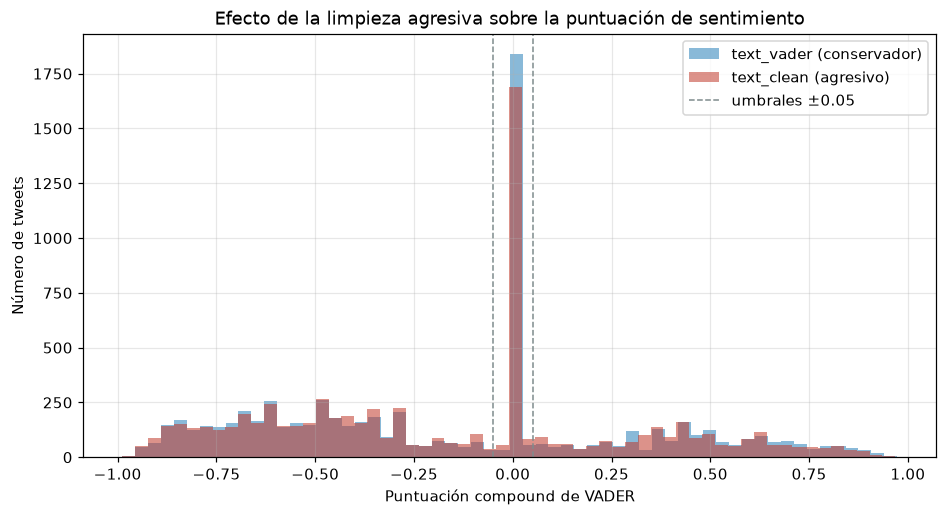

In [8]:
fig, ax = plt.subplots(figsize=(config.FIG_ANCHO, config.FIG_ALTO))
for col, color, etq in [('text_vader', config.COLOR_NO_DESASTRE, 'text_vader (conservador)'),
                        ('text_clean', config.COLOR_DESASTRE, 'text_clean (agresivo)')]:
    ax.hist(versiones[col], bins=60, alpha=0.55, color=color, label=etq)
ax.axvline(config.UMBRAL_POSITIVO, color=config.COLOR_NEUTRO, ls='--', lw=1)
ax.axvline(config.UMBRAL_NEGATIVO, color=config.COLOR_NEUTRO, ls='--', lw=1,
           label='umbrales ±0.05')
ax.set_xlabel('Puntuación compound de VADER')
ax.set_ylabel('Número de tweets')
ax.set_title('Efecto de la limpieza agresiva sobre la puntuación de sentimiento')
ax.legend()
guardar(fig, 'sentimiento_versiones_texto.png')
plt.show()

In [9]:
comparacion = df[cambian].copy()
comparacion['compound_conservador'] = versiones['text_vader'][cambian]
comparacion['compound_agresivo'] = versiones['text_clean'][cambian]
comparacion['salto'] = (comparacion.compound_conservador - comparacion.compound_agresivo).abs()

ejemplos = comparacion.nlargest(5, 'salto')[
    ['text', 'text_clean', 'compound_conservador', 'compound_agresivo']]
guardar_tabla(ejemplos, 'sentimiento_ejemplos_limpieza.csv')

for _, r in ejemplos.iterrows():
    print(f'crudo   : {r.text[:100]}')
    print(f'limpiado: {r.text_clean[:100]}')
    print(f'compound: {r.compound_conservador:+.4f}  ->  {r.compound_agresivo:+.4f}')
    print()

tabla guardada: sentimiento_ejemplos_limpieza.csv
crudo   : What the fuck was that. There was a loud bang and a flash of light outside. I'm pretty sure I'm not 
limpiado: fuck loud bang flash light outside pretty sure not dead hell
compound: -0.7218  ->  +0.8445

crudo   : Another movie theater attack..close to home this time. Thankful for no casualties. Life will go on b
limpiado: another movie theater attack close home time thankful no casualty life go not allow evil win
compound: +0.8570  ->  -0.6395

crudo   : Be not afraid of sudden fear neither of the desolation of the wicked when it cometh. For the Lord sh
limpiado: not afraid sudden fear neither desolation wicked cometh lord shall thy urlweb
compound: -0.7650  ->  +0.6602

crudo   : I'm gunning down romance
It never did a thing for me
But heartache and misery
Ain't nothing but a tr
limpiado: gunning romance never thing heartache misery ai n't nothing tragedy urlweb
compound: -0.8197  ->  +0.5770

crudo   : @I_AmTalia @SGC72 'Th

**Interpretación.** **501 tweets, el 6.69% del corpus, cambian de etiqueta de polaridad**
según se puntúe el texto conservador o el agresivamente limpiado. Y no cambian un poco: los
cinco casos de mayor salto **invierten el signo por completo**.

El ejemplo más claro es *"Another movie theater attack..close to home this time. Thankful for
no casualties."* Con el texto conservador el `compound` es **+0.8570**, porque VADER lee
`thankful for no casualties` como lo que es: alivio. Tras la limpieza agresiva el texto queda
como `another movie theater attack close home time thankful no casualty...` y el `compound`
cae a **-0.6395**. Al perderse la estructura de la frase, `attack` y `casualty` pesan como
términos sueltos y el alivio se convierte en catástrofe.

El caso inverso también aparece: *"I'm pretty sure I'm not dead"* pasa de **-0.7218** a
**+0.8445**. La conclusión es simétrica y no depende de la dirección del error: **la limpieza
pensada para clasificar por tema destruye la señal que el análisis de sentimiento necesita.**

Esto valida la decisión de diseño que el equipo tomó en el ejercicio 3 de mantener **dos
limpiezas separadas** en lugar de una sola. La diferencia entre el texto crudo y `text_vader`
es en cambio pequeña —solo **114 tweets, el 1.52%**, cambian de etiqueta— lo que confirma que
quitar URLs y menciones es seguro: no cargan opinión.

## Los emoticones: la pregunta del enunciado, respondida con evidencia

El ejercicio 8 pregunta de forma explícita: *"¿valdrá la pena dejar los emoticones y
analizarlos?"*

El análisis exploratorio inicial ya había medido que el corpus **no tiene ni un solo emoji
Unicode** y que los emoticones ASCII aparecen en menos del 1% de los tweets. Con esos números
la respuesta parecería ser "no importa". Pero hay un detalle que cambia el planteamiento y que
solo se ve al mirar el léxico: **VADER ya trae los emoticones puntuados**.

In [10]:
analizador = sent._analizador()
print('Emoticones en el léxico de VADER:')
for e in [':)', ':-)', ':D', ':(', ':-(', '<3', ';)']:
    print(f'   {e:5s} -> valencia {analizador.lexicon.get(e, "AUSENTE")}')
print()
print('Tokens a los que `limpiar_sentimiento` traduce los emoticones:')
for e in ['emoji_feliz', 'emoji_triste', 'emoji_amor']:
    print(f'   {e:12s} -> {analizador.lexicon.get(e, "AUSENTE")}')

Emoticones en el léxico de VADER:
   :)    -> valencia 2.0
   :-)   -> valencia 1.3
   :D    -> valencia 2.3
   :(    -> valencia -1.9
   :-(   -> valencia -1.5
   <3    -> valencia 1.9
   ;)    -> valencia 0.9

Tokens a los que `limpiar_sentimiento` traduce los emoticones:
   emoji_feliz  -> AUSENTE
   emoji_triste -> AUSENTE
   emoji_amor   -> AUSENTE


In [11]:
from preprocesamiento import RE_EMOTICON_AMOR, RE_EMOTICON_FELIZ, RE_EMOTICON_TRISTE

tiene_emoticon = df.text.apply(
    lambda t: bool(RE_EMOTICON_FELIZ.search(t) or RE_EMOTICON_TRISTE.search(t)
                   or RE_EMOTICON_AMOR.search(t)))
emo = df[tiene_emoticon].copy()

emo['compound_literal'] = versiones['text_vader'][tiene_emoticon]
emo['compound_traducido'] = versiones['text_sent'][tiene_emoticon]
emo['etq_literal'] = emo.compound_literal.map(sent.etiquetar_polaridad)
emo['etq_traducido'] = emo.compound_traducido.map(sent.etiquetar_polaridad)

cambian_emo = (emo.etq_literal != emo.etq_traducido)

tabla_emo = pd.DataFrame([{
    'tweets_con_emoticon': len(emo),
    'pct_del_corpus': len(emo) / len(df) * 100,
    'compound_medio_literal': emo.compound_literal.mean(),
    'compound_medio_traducido': emo.compound_traducido.mean(),
    'cambian_de_etiqueta': int(cambian_emo.sum()),
    'pct_cambian': cambian_emo.mean() * 100,
    'tasa_desastre': emo.target.mean() * 100,
}])
guardar_tabla(tabla_emo, 'sentimiento_emoticones.csv')
tabla_emo.round(4).T.rename(columns={0: 'valor'})

tabla guardada: sentimiento_emoticones.csv


,valor
tweets_con_emoticon,52.0000
pct_del_corpus,0.6947
compound_medio_literal,0.2175
compound_medio_traducido,0.0611
cambian_de_etiqueta,19.0000
pct_cambian,36.5385
tasa_desastre,13.4615


**Interpretación: la respuesta es sí, y el motivo no es el que parecía.**

VADER trae los emoticones en su léxico con valencias reales: `:)` vale **2.0**, `:D` vale
**2.3**, `:(` vale **-1.9** y `<3` vale **1.9**. En cambio los tokens `emoji_feliz`,
`emoji_triste` y `emoji_amor` a los que `limpiar_sentimiento` los traduce **no existen en el
léxico**, así que VADER los ignora por completo.

El efecto es medible: de los **52 tweets** del corpus con emoticón ASCII, **19 cambian de
etiqueta de polaridad —el 36.54%—** según se les deje el emoticón literal o traducido. El
`compound` medio del grupo cae de **+0.2175 a +0.0611** al traducirlos, es decir se pierde
alrededor de tres cuartas partes de la señal que aportaban.

Conviene ser preciso sobre la magnitud: **son 52 tweets sobre 7,485, el 0.69% del corpus**, así
que el efecto agregado sobre cualquier métrica global es despreciable. La respuesta honesta
tiene entonces dos partes:

1. **Sí vale la pena conservarlos y analizarlos**, y además conservarlos **literales**, sin
   traducir, porque la herramienta ya sabe leerlos. Por eso este cuaderno puntúa sobre
   `text_vader` y no sobre `text_sent`.
2. **En este corpus concreto da casi igual**, porque casi no hay. La conclusión importa como
   criterio de método —traducir un símbolo que la herramienta ya entiende es perder
   información gratis— más que como mejora de resultados aquí.

Vale la pena notar que la traducción a `emoji_feliz` **no es un error del preprocesamiento del
ejercicio 3**: es la decisión correcta para un clasificador de bolsa de palabras, donde el tokenizador descartaría
`:)` como puntuación suelta y la señal se perdería del todo. Lo que muestra este análisis es
que la limpieza óptima depende de la herramienta que consume el texto, no solo de la tarea.

Un dato secundario: estos 52 tweets tienen una tasa de desastre real del **13.46%**, muy por
debajo del 42.6% global. Quien escribe `:)` no suele estar reportando una catástrofe. Con 52
casos la base es pequeña, y así se reporta.

## Umbrales de polaridad y su sensibilidad

Los umbrales usados son los estándar de VADER, declarados en `src/config.py`:
`compound >= 0.05` es positivo, `compound <= -0.05` es negativo, y el intervalo intermedio es
neutro. **Son una decisión, no una ley**, así que conviene mostrar qué tan sensible es el
resultado a moverlos.

In [12]:
filas_umbral = []
for u in [0.05, 0.1, 0.2, 0.3]:
    etq = df.compound.map(lambda x: 'positivo' if x >= u else ('negativo' if x <= -u else 'neutro'))
    d = etq.value_counts(normalize=True) * 100
    filas_umbral.append({'umbral': u,
                         'pct_negativo': d.get('negativo', 0),
                         'pct_neutro': d.get('neutro', 0),
                         'pct_positivo': d.get('positivo', 0)})

tabla_umbral = pd.DataFrame(filas_umbral)
guardar_tabla(tabla_umbral, 'sentimiento_umbrales.csv')
tabla_umbral.round(2)

tabla guardada: sentimiento_umbrales.csv


,umbral,pct_negativo,pct_neutro,pct_positivo
0,0.05,49.25,25.42,25.33
1,0.10,48.30,27.55,24.15
2,0.20,45.91,31.92,22.18
3,0.30,41.26,39.39,19.36


**Interpretación.** El reparto es **estable**. Al pasar el umbral de ±0.05 a ±0.2 la
proporción de neutros sube del 25.42% al 31.92% y la de negativos baja del 49.25% al 45.91%.
Incluso llevándolo a ±0.3 los neutros llegan al 39.39% y los negativos siguen siendo el grupo
mayoritario con el 41.26%. El movimiento es apreciable pero no reordena nada.

La dirección del cambio es la esperable. Al ampliar la banda neutra, los tweets de polaridad
débil —típicamente los cortos, que tienen pocas palabras con carga— se reclasifican como
neutros. Que la conclusión principal no dependa del umbral elegido es lo que permite
reportarla sin advertencias.

## Contraste con una segunda herramienta: TextBlob

Medir sentimiento con una sola herramienta deja sin responder si el resultado es una
propiedad del corpus o del método. Se repite la medición con **TextBlob**, que el enunciado
lista entre los módulos útiles, y se reporta el grado de acuerdo.

In [13]:
anotado = sent.anotar_dataframe(df, columna='text_vader')
anotado['etiqueta_textblob'] = anotado.textblob_polarity.map(sent.etiquetar_polaridad)

acuerdo_tb = (anotado.polaridad == anotado.etiqueta_textblob).mean()
correlacion = anotado.vader_compound.corr(anotado.textblob_polarity, method='spearman')

mc_tb = pd.crosstab(anotado.polaridad, anotado.etiqueta_textblob)
guardar_tabla(mc_tb, 'sentimiento_vader_vs_textblob.csv', index=True)

print(f'Acuerdo VADER vs TextBlob: {acuerdo_tb*100:.2f}%')
print(f'Correlación de Spearman:   {correlacion:.4f}')
print(f'Neutros según TextBlob:    {(anotado.etiqueta_textblob=="neutro").mean()*100:.2f}%')
print(f'Neutros según VADER:       {(anotado.polaridad=="neutro").mean()*100:.2f}%')
print()
print('Matriz de acuerdo (filas = VADER, columnas = TextBlob):')
mc_tb

tabla guardada: sentimiento_vader_vs_textblob.csv
Acuerdo VADER vs TextBlob: 47.07%
Correlación de Spearman:   0.4014
Neutros según TextBlob:    49.65%
Neutros según VADER:       25.42%

Matriz de acuerdo (filas = VADER, columnas = TextBlob):


etiqueta_textblob,negativo,neutro,positivo
polaridad,,,
negativo,1122,1777,787
neutro,160,1308,435
positivo,172,631,1093


**Interpretación.** Las dos herramientas coinciden en apenas el **47.07%** de los tweets, con
una correlación de Spearman de **0.4014**. Es un desacuerdo grande y es, en sí mismo, el
hallazgo de esta sección.

La causa principal se lee en la matriz: **TextBlob clasifica como neutro el 49.65% del corpus,
casi el doble que VADER (25.42%)**. La discrepancia mayor está en la celda de 1,777 tweets que
VADER llama negativos y TextBlob llama neutros. La explicación es de diseño: TextBlob usa el
léxico de *pattern*, construido para prosa general —reseñas, texto editado— y **no incluye
emoticones, jerga de redes sociales ni reglas para mayúsculas o signos de exclamación**.
Frente a un tweet, se queda sin vocabulario que puntuar y devuelve 0.

La conclusión metodológica es que **la medición de sentimiento es sensible al método, y
reportar una cifra de una sola herramienta sin contraste transmite más certeza de la que
existe**. Para este corpus se elige VADER por estar calibrado al dominio, pero los resultados
de las secciones siguientes deben leerse como "según VADER", no como una propiedad absoluta
de los tweets.

---

# Ejercicio 9 — Las interrogantes

## 9.1 Los 10 tweets más negativos, y en qué categoría están

In [14]:
cols_ver = ['text', 'vader_compound', 'negatividad', 'target']
top10_neg = anotado.nsmallest(10, 'vader_compound')[cols_ver].copy()
top10_neg['categoria'] = top10_neg.target.map(config.ETIQUETAS)
guardar_tabla(top10_neg, 'sentimiento_top10_negativos.csv')

print(f'De los 10 más negativos, {int(top10_neg.target.sum())} son de desastre real.')
print()
for i, (_, r) in enumerate(top10_neg.iterrows(), 1):
    print(f'{i:2d}. compound {r.vader_compound:+.4f}  [{config.ETIQUETAS[r.target]}]')
    print(f'    {r.text[:110]}')

tabla guardada: sentimiento_top10_negativos.csv
De los 10 más negativos, 8 son de desastre real.

 1. compound -0.9883  [no desastre]
    wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?
 2. compound -0.9686  [desastre]
    @Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at leas
 3. compound -0.9623  [desastre]
    Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an attac
 4. compound -0.9595  [desastre]
    ? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. Times
 5. compound -0.9552  [desastre]
    17 killed in SÛªArabia mosque suicide bombing

A suicide bomber attacked a mosque in Aseer south-western Saud
 6. compound -0.9549  [no desastre]
    at the lake 
*sees a dead fish*
me: poor little guy i wonder what happened
ashley: idk maybe it drowned
  wtf 
 7. compound -0.9538  [desastre]
    il

**Interpretación.** **8 de los 10 tweets más negativos son de desastre real.** El contenido es
inequívoco: atentados suicidas en Arabia Saudita y Nigeria, muertes, bombas. Es vocabulario de
catástrofe usado en sentido literal, y VADER lo puntúa correctamente con valores por debajo de
-0.95.

Los dos que **no** son de desastre son instructivos. El primero, y el más negativo de todo el
corpus con `compound = -0.9883`, es la repetición literal de la palabra `wreck` trece veces.
VADER acumula la valencia de cada repetición y llega casi al extremo de la escala, pero el
tweet no reporta ningún evento: **es un artefacto de la aritmética del léxico**, que suma
ocurrencias sin advertir que se trata de la misma palabra repetida. El segundo describe un pez
muerto en un lago, un suceso menor narrado con lenguaje dramático.

Ambos casos apuntan a lo mismo: **negatividad extrema no equivale a desastre real**, ni
siquiera en el extremo de la distribución donde la asociación es más fuerte.

## 9.2 Los 10 tweets más positivos, y en qué categoría están

In [15]:
top10_pos = anotado.nlargest(10, 'vader_compound')[cols_ver].copy()
top10_pos['categoria'] = top10_pos.target.map(config.ETIQUETAS)
guardar_tabla(top10_pos, 'sentimiento_top10_positivos.csv')

print(f'De los 10 más positivos, {int(top10_pos.target.sum())} son de desastre real.')
print()
for i, (_, r) in enumerate(top10_pos.iterrows(), 1):
    print(f'{i:2d}. compound {r.vader_compound:+.4f}  [{config.ETIQUETAS[r.target]}]')
    print(f'    {r.text[:110]}')

tabla guardada: sentimiento_top10_positivos.csv
De los 10 más positivos, 2 son de desastre real.

 1. compound +0.9730  [no desastre]
    Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at  http://t.co/3GEROQ49o1
I 
 2. compound +0.9564  [no desastre]
    @thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've survived all of them. Hope y
 3. compound +0.9471  [desastre]
    TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this loving warmth; let your 
 4. compound +0.9423  [no desastre]
    @batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run
 5. compound +0.9376  [no desastre]
    Free Ebay Sniping RT? http://t.co/B231Ul1O1K Lumbar Extender Back Stretcher Excellent Condition!! ?Please Favo
 6. compound +0.9356  [desastre]
    @Raishimi33 :) well I think that sounds like a fine plan where little derailment is possible so I applaud you 
 7

**Interpretación.** El resultado es casi el espejo del anterior: **8 de los 10 tweets más
positivos no son de desastre real.** Son promociones, entusiasmo por una serie, canciones de
amor y agradecimientos: registro conversacional cotidiano.

Los dos etiquetados como desastre real merecen atención porque explican algo del conjunto, y
son casos distintos entre sí:

- *"Today's storm will pass; let tomorrow's light greet you with a kiss. Bask in this loving
  warmth..."* es un mensaje inspiracional que usa `storm` como metáfora, no un reporte de un
  temporal. Está etiquetado con `target = 1`, lo que muy probablemente sea **ruido de
  anotación**.
- *"@Raishimi33 :) well I think that sounds like a fine plan where little **derailment** is
  possible so I applaud you"* usa `derailment` en sentido figurado, para hablar de un plan que
  difícilmente se descarrile. Es especialmente llamativo porque el análisis exploratorio había
  medido que `derailment` tiene una tasa de desastre real del **100%**: era una de las
  keywords más inequívocas del corpus. Aquí aparece el contraejemplo.

Ambos son el mismo fenómeno de uso figurado que atraviesa todo el laboratorio, esta vez
confundiendo a los anotadores humanos y no al modelo.

Vale notar la asimetría entre 9.1 y 9.2. En el extremo negativo la asociación con desastre
real es fuerte (8 de 10); en el extremo positivo la asociación con "no desastre" es igual de
fuerte (8 de 10). **El sentimiento discrimina en ambos extremos, pero solo en los extremos**:
es en el centro de la distribución, donde vive la mayoría del corpus, donde deja de separar.

## 9.3 ¿Son los tweets de desastre real más negativos que los demás?

**Sí, la diferencia existe y es estadísticamente indiscutible, pero su magnitud es moderada y
el matiz importa más que el promedio.** El sustento viene a continuación.

Se comparan las distribuciones completas y no solo las medias, porque una media puede ocultar
formas muy distintas. La prueba es **Mann-Whitney U**, que no asume normalidad —la
distribución del `compound` está lejos de ser normal, con una acumulación fuerte en el cero— y
se acompaña del **tamaño del efecto** mediante la correlación rango-biserial. Con 7,485
observaciones casi cualquier diferencia sale significativa, así que el valor p por sí solo no
dice nada útil: lo relevante es si la diferencia es **grande**.

In [16]:
resumen_clase = anotado.groupby('target').agg(
    n=('vader_compound', 'size'),
    compound_medio=('vader_compound', 'mean'),
    compound_mediana=('vader_compound', 'median'),
    compound_desv=('vader_compound', 'std'),
    negatividad_media=('negatividad', 'mean'),
    negatividad_mediana=('negatividad', 'median'),
).reset_index()
resumen_clase['categoria'] = resumen_clase.target.map(config.ETIQUETAS)

desastre = anotado.loc[anotado.target == 1, 'vader_compound']
no_desastre = anotado.loc[anotado.target == 0, 'vader_compound']

u_stat, p_valor = mannwhitneyu(desastre, no_desastre, alternative='two-sided')
# Correlacion rango-biserial: tamano de efecto derivado de U, en [-1, 1].
r_rb = 1 - (2 * u_stat) / (len(desastre) * len(no_desastre))

guardar_tabla(resumen_clase, 'sentimiento_comparacion_clases.csv')

print(resumen_clase.round(4).to_string(index=False))
print()
print(f'Mann-Whitney U = {u_stat:,.0f}')
print(f'valor p        = {p_valor:.3e}')
print(f'tamaño del efecto (r rango-biserial) = {r_rb:.4f}')

tabla guardada: sentimiento_comparacion_clases.csv
 target    n  compound_medio  compound_mediana  compound_desv  negatividad_media  negatividad_mediana   categoria
      0 4297         -0.0571            0.0000         0.4623             0.5285               0.5000 no desastre
      1 3188         -0.2692           -0.3182         0.4338             0.6346               0.6591    desastre

Mann-Whitney U = 5,088,009
valor p        = 3.945e-82
tamaño del efecto (r rango-biserial) = 0.2572


In [17]:
reparto = pd.crosstab(anotado.target, anotado.polaridad, normalize='index') * 100
reparto.index = reparto.index.map(config.ETIQUETAS)
guardar_tabla(reparto, 'sentimiento_polaridad_por_clase.csv', index=True)
print('Reparto de polaridad dentro de cada categoría (%):')
reparto.round(2)

tabla guardada: sentimiento_polaridad_por_clase.csv
Reparto de polaridad dentro de cada categoría (%):


polaridad,negativo,neutro,positivo
target,,,
no desastre,42.91,24.99,32.09
desastre,57.78,26.00,16.22


figura guardada: sentimiento_compound_por_clase.png


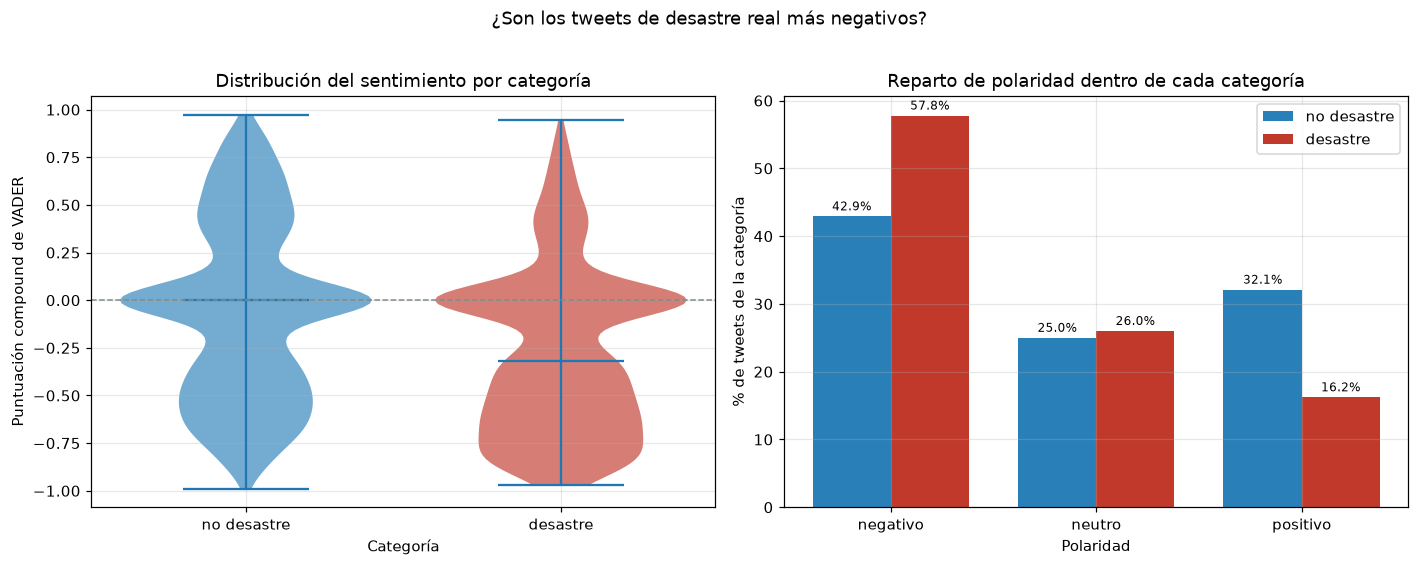

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(config.FIG_ANCHO + 3, config.FIG_ALTO))

datos = [no_desastre.values, desastre.values]
partes = axes[0].violinplot(datos, showmedians=True, widths=0.8)
for cuerpo, color in zip(partes['bodies'], [config.COLOR_NO_DESASTRE, config.COLOR_DESASTRE]):
    cuerpo.set_facecolor(color)
    cuerpo.set_alpha(0.65)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels([config.ETIQUETAS[0], config.ETIQUETAS[1]])
axes[0].axhline(0, color=config.COLOR_NEUTRO, ls='--', lw=1)
axes[0].set_ylabel('Puntuación compound de VADER')
axes[0].set_xlabel('Categoría')
axes[0].set_title('Distribución del sentimiento por categoría')

orden = ['negativo', 'neutro', 'positivo']
x = np.arange(len(orden))
ancho = 0.38
for i, (tgt, color) in enumerate([(0, config.COLOR_NO_DESASTRE), (1, config.COLOR_DESASTRE)]):
    valores = [reparto.loc[config.ETIQUETAS[tgt], o] for o in orden]
    barras = axes[1].bar(x + (i - 0.5) * ancho, valores, ancho,
                         color=color, label=config.ETIQUETAS[tgt])
    axes[1].bar_label(barras, fmt='%.1f%%', fontsize=8, padding=2)
axes[1].set_xticks(x)
axes[1].set_xticklabels(orden)
axes[1].set_ylabel('% de tweets de la categoría')
axes[1].set_xlabel('Polaridad')
axes[1].set_title('Reparto de polaridad dentro de cada categoría')
axes[1].legend()

fig.suptitle('¿Son los tweets de desastre real más negativos?', y=1.02)
fig.tight_layout()
guardar(fig, 'sentimiento_compound_por_clase.png')
plt.show()

**Interpretación: sí, pero con un matiz que es el hallazgo de la sección.**

Los tweets de desastre real **son medibles más negativos**. Su `compound` medio es **-0.2692**
frente a **-0.0571** de los demás, y la mediana marca aún mejor el contraste: **-0.3182 contra
0.0000**. La mediana de la clase "no desastre" es exactamente cero, es decir el tweet típico
que no habla de un desastre no tiene carga de sentimiento en absoluto. En negatividad, la
media pasa de 0.5285 a 0.6346.

La prueba de Mann-Whitney da `U = 5,088,009` con **p ≈ 3.9×10⁻⁸²**. La diferencia no es
atribuible al azar bajo ninguna lectura razonable. Pero el **tamaño del efecto es r = 0.2572**,
que en las convenciones habituales es un efecto **pequeño a moderado**, no grande. Esa es la
cifra que hay que reportar junto al valor p: con 7,485 observaciones, un p astronómicamente
pequeño acompaña a diferencias modestas, y confundir significancia con magnitud sería el error
clásico.

El violín de la Figura 3 muestra por qué. Las dos distribuciones **se solapan ampliamente**.
La de desastre está desplazada hacia abajo, pero no es un bloque separado: es la misma forma
corrida. Un tweet tomado al azar de la clase desastre es más probablemente negativo, pero
saber que es negativo no permite afirmar que sea de desastre.

El reparto por categoría lo cuantifica:

| Categoría | Negativo | Neutro | Positivo |
|---|---|---|---|
| No desastre | 42.91% | 24.99% | 32.09% |
| Desastre real | 57.78% | 26.00% | 16.22% |

Los dos números que más dicen no son los de la columna "negativo" sino los otros dos.
**El 26.00% de los tweets de desastre real son neutros** —reportes periodísticos factuales del
tipo *"13,000 people receive #wildfires evacuation orders in California"*, que informa de una
catástrofe sin una sola palabra cargada— y **un 16.22% son directamente positivos**: rescates,
supervivientes, agradecimientos. En conjunto, **más de cuatro de cada diez tweets de desastre
real (42.22%) no son negativos**. Al mismo tiempo, el 42.91% de los que no describen ningún
desastre sí lo son, porque la gente tuitea sobre su mal día con lenguaje catastrófico.

**Consecuencia directa para el ejercicio 10.** Polaridad y factualidad son dimensiones
distintas. Un tweet puede ser negativo sin hablar de un desastre, y puede reportar un desastre
sin ser negativo. Esto **anticipa que la variable de negatividad aportará poco al clasificador**
y respalda con datos la hipótesis que el análisis exploratorio ya había formulado al observar
que los tweets de desastre son más factuales y menos emocionales. Que la variable no mejore el
modelo será un resultado coherente con esta sección, no un fracaso.

---

## El conjunto anotado que consume el ejercicio 10

Se guarda el DataFrame con todas las columnas del contrato de `src/sentimiento.py` en
`data/processed/tweets_con_sentimiento.parquet`, que es lo que el ejercicio 10 consume para
reentrenar el clasificador.

Se incluyen también las columnas de conteo del ejercicio 8 (`n_positivas`, `n_negativas`,
`n_neutras`, `balance`) por si resultan útiles como características alternativas, y las
versiones del texto para no tener que regenerarlas más adelante.

In [19]:
columnas_entrega = [
    'id', 'keyword', 'location', 'text', 'target',
    'text_clean', 'text_stem', 'text_sent', 'text_vader',
    'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
    'polaridad', 'negatividad',
    'textblob_polarity', 'textblob_subjectivity',
    'n_positivas', 'n_negativas', 'n_neutras', 'balance',
]

entrega = anotado.copy()
entrega['text_stem'] = df['text'].apply(
    lambda t: ' '.join(pipeline_texto(t, modo='clasificacion', reduccion='stem', quitar_numeros=False)))
entrega = entrega[columnas_entrega]

entrega.to_parquet(config.TWEETS_SENTIMIENTO, index=False)

print(f'Guardado en {config.TWEETS_SENTIMIENTO.relative_to(RAIZ)}')
print(f'{len(entrega):,} filas x {entrega.shape[1]} columnas')
print()
print('Verificación de integridad:')
print(f'  nulos en negatividad:     {entrega.negatividad.isna().sum()}')
print(f'  rango de negatividad:     [{entrega.negatividad.min():.4f}, {entrega.negatividad.max():.4f}]')
print(f'  rango de vader_compound:  [{entrega.vader_compound.min():.4f}, {entrega.vader_compound.max():.4f}]')
print(f'  ids únicos:               {entrega.id.nunique():,} de {len(entrega):,}')
print()
entrega.head(3)

Guardado en data\processed\tweets_con_sentimiento.parquet
7,485 filas x 21 columnas

Verificación de integridad:
  nulos en negatividad:     0
  rango de negatividad:     [0.0135, 0.9941]
  rango de vader_compound:  [-0.9883, 0.9730]
  ids únicos:               7,485 de 7,485



,id,keyword,location,text,target,text_clean,text_stem,text_sent,text_vader,vader_neg,...,vader_pos,vader_compound,polaridad,negatividad,textblob_polarity,textblob_subjectivity,n_positivas,n_negativas,n_neutras,balance
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,deed reason earthquake may allah forgive,deed reason earthquak may allah forgiv,Our Deeds are the Reason of this earthquake May ALLAH Forgive us all,Our Deeds are the Reason of this earthquake May ALLAH Forgive us all,0.000,...,0.149,0.2732,positivo,0.3634,0.00000,0.0000,1,0,12,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,forest fire near la ronge sask canada,forest fire near la rong sask canada,Forest fire near La Ronge Sask. Canada,Forest fire near La Ronge Sask. Canada,0.286,...,0.000,-0.3400,negativo,0.6700,0.10000,0.4000,0,1,6,-1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuati...,1,resident asked shelter place notified officer no evacuation shelter place order expected,resid ask shelter place notifi offic no evacu shelter place order expect,All residents asked to 'shelter in place' are being notified by officers. No other evacuati...,All residents asked to 'shelter in place' are being notified by officers. No other evacuati...,0.095,...,0.000,-0.2960,negativo,0.6480,-0.01875,0.3875,0,1,21,-1


In [20]:
# La particion congelada del ejercicio 6 tiene que seguir alineada con este conjunto.
if config.PARTICION.exists():
    particion = pd.read_parquet(config.PARTICION)
    comunes = set(entrega.id) & set(particion.id)
    print(f'Partición congelada encontrada: {len(particion):,} filas')
    print(f'  ids que coinciden con el conjunto anotado: {len(comunes):,}')
    print('  OK: el ejercicio 10 puede reentrenar sobre la misma partición.'
          if len(comunes) == len(entrega) else '  ATENCIÓN: hay ids que no coinciden.')
else:
    print('Aún no existe la partición congelada del ejercicio 6.')

Partición congelada encontrada: 7,485 filas
  ids que coinciden con el conjunto anotado: 7,485
  OK: el ejercicio 10 puede reentrenar sobre la misma partición.


## Síntesis de los ejercicios 8 y 9

**Sobre el método**

1. Se usó **VADER** por estar calibrado a redes sociales y manejar negación, intensificadores,
   mayúsculas y emoticones. El corpus no tiene etiquetas de sentimiento, así que un enfoque
   léxico es la única vía posible.
2. Solo el **9.91%** del vocabulario tiene carga de sentimiento según el léxico. Las palabras
   que deciden el sentimiento del corpus son las que combinan carga alta con frecuencia alta,
   no las de valencia extrema.
3. El conteo ingenuo de palabras coincide con VADER en el **85.12%** de los casos. De las 116
   discrepancias en que el conteo dice negativo y VADER positivo, **94 se explican por una
   negación explícita**, lo que justifica usar `compound` y no el conteo como medida oficial.
4. **La limpieza agresiva destruye la señal de sentimiento**: el **6.69%** de los tweets cambia
   de etiqueta, con inversiones completas de signo. Se puntúa sobre texto conservador.
5. **Sí vale la pena conservar los emoticones, y literales**, porque VADER ya los tiene en su
   léxico. Traducirlos a `emoji_feliz` los vuelve invisibles para la herramienta. El efecto es
   real (36.54% de esos tweets cambian de etiqueta) pero afecta a solo 52 tweets.
6. **VADER y TextBlob solo coinciden en el 47.07%.** La medición de sentimiento depende del
   método, y los resultados deben leerse como "según VADER".

**Sobre las interrogantes**

7. **8 de los 10 tweets más negativos** son de desastre real; **8 de los 10 más positivos** no
   lo son. El sentimiento separa bien en los extremos y deja de separar en el centro.
8. **Los tweets de desastre real sí son más negativos** (compound medio -0.2692 contra -0.0571,
   p ≈ 3.9×10⁻⁸²), pero el tamaño del efecto es **moderado** (r = 0.2572) y las distribuciones
   se solapan mucho.
9. **Más de cuatro de cada diez tweets de desastre real no son negativos**: el 26.00% son
   neutros y factuales, y el 16.22% son positivos. Polaridad y factualidad son dimensiones
   distintas, lo que **anticipa que la variable de negatividad aportará poco al ejercicio 10**.